## Convert nuScenes (local folder) to KITTI format

This notebook converts the nuScenes **v1.0-mini** dataset located at:

- `/OpenPCDet/datasets/nuscenes/v1.0-mini`

into a KITTI-style folder structure using `nuscenes-devkit`'s `nuscenes/scripts/export_kitti.py`.

Notes:
- The devkit's `KittiConverter` hardcodes nuScenes `dataroot` to `/data/sets/nuscenes`, so we create a symlink at that path pointing to the local dataset folder.

In [36]:
# Verify that nuscenes-devkit is importable in this environment.
import nuscenes
print('nuscenes-devkit:', nuscenes.__file__)

nuscenes-devkit: /usr/local/lib/python3.8/dist-packages/nuscenes/__init__.py


In [37]:
from pathlib import Path
from PIL import Image

In [38]:
# Local nuScenes mini dataset root.
# This folder should contain: samples/, sweeps/, maps/, and v1.0-mini/*.json
NUSC_ROOT = Path('/OpenPCDet/datasets/nuscenes/v1.0-mini')
NUSC_ROOT

PosixPath('/OpenPCDet/datasets/nuscenes/v1.0-mini')

In [39]:
# nuScenes version + split to export.
# For v1.0-mini, valid splits are typically: mini_train, mini_val
NUSC_VERSION = 'v1.0-mini'
SPLIT = 'mini_train'
IMAGE_COUNT = 20000000  # set larger (or very large) to export more samples

# Basic sanity checks.
assert NUSC_ROOT.exists(), f'Missing: {NUSC_ROOT}'
assert (NUSC_ROOT / NUSC_VERSION).exists(), f'Missing tables: {NUSC_ROOT / NUSC_VERSION}'
print('OK:', NUSC_ROOT)

OK: /OpenPCDet/datasets/nuscenes/v1.0-mini


In [40]:
# IMPORTANT:
# nuscenes-devkit's export_kitti.KittiConverter currently constructs NuScenes() with the default
# dataroot='/data/sets/nuscenes'. To make it see our local dataset, we create a symlink.

import os

link_path = Path('/data/sets/nuscenes')
link_path.parent.mkdir(parents=True, exist_ok=True)

# Create or update the symlink to point at our dataset.
if link_path.exists() or link_path.is_symlink():
    if link_path.is_symlink():
        current_target = link_path.resolve()
        if current_target != NUSC_ROOT.resolve():
            link_path.unlink()
            link_path.symlink_to(NUSC_ROOT, target_is_directory=True)
            print('Updated symlink:', link_path, '->', NUSC_ROOT)
        else:
            print('Symlink already OK:', link_path, '->', current_target)
    else:
        raise RuntimeError(
            f'{link_path} exists and is not a symlink. '
            'Either remove it or edit export_kitti.py to pass an explicit dataroot.'
        )
else:
    link_path.symlink_to(NUSC_ROOT, target_is_directory=True)
    print('Created symlink:', link_path, '->', NUSC_ROOT)

Symlink already OK: /data/sets/nuscenes -> /OpenPCDet/datasets/nuscenes/v1.0-mini


In [41]:
# Output folder for the KITTI-style dataset.
# export_kitti will create subfolders under: {STORE_DIR}/{SPLIT}/...
STORE_DIR = Path('/OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format') 
STORE_DIR

PosixPath('/OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format')

In [42]:
# (Optional) start clean.
# WARNING: This deletes the entire STORE_DIR folder if it exists.
!rm -rf {STORE_DIR}
!mkdir -p {STORE_DIR}
print('STORE_DIR:', STORE_DIR)

STORE_DIR: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format


In [43]:
# Show the built-in docstring from nuscenes-devkit (avoids Fire "-h" paging issues).
import inspect
import nuscenes.scripts.export_kitti as export_kitti

print(export_kitti.__doc__.strip().splitlines()[0])
print('KittiConverter args:', inspect.signature(export_kitti.KittiConverter))

This script converts nuScenes data to KITTI format and KITTI results to nuScenes.
KittiConverter args: (nusc_kitti_dir: str = '~/nusc_kitti', cam_name: str = 'CAM_FRONT', lidar_name: str = 'LIDAR_TOP', image_count: int = 10, nusc_version: str = 'v1.0-mini', split: str = 'mini_train')


In [44]:
# Convert nuScenes GT annotations to KITTI format.
# This writes label_2/, calib/, image_2/, velodyne/ under: {STORE_DIR}/{SPLIT}/
import sys

!{sys.executable} -m nuscenes.scripts.export_kitti nuscenes_gt_to_kitti \
    --nusc_kitti_dir {STORE_DIR} \
    --nusc_version {NUSC_VERSION} \
    --split {SPLIT} \
    --image_count {IMAGE_COUNT}

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.3 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Writing file: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/mini_train/label_2/ca9a282c9e77460f8360f564131a8af5.txt
Writing file: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/mini_train/label_2/39586f9d59004284a7114a68825e8eec.txt
Writing file: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/mini_train/label_2/356d81f38dd9473ba590f39e266f54e5.txt
Writing file: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/mini_train/label_2/e0845f5322254dafadbbed75aaa07969.txt
Writing file: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/mini_train/label_2/c923fe08b2ff4e27975d2bf30934383b.txt
Writing file: /Open

In [45]:
# Check created (converted) LiDAR point clouds (KITTI velodyne/*.bin).
!ls {STORE_DIR}/{SPLIT}/velodyne | head -5

00889f8a9549450aa2f32cf310a3e305.bin
0106a9b8e65f4ad1867b44591aeed8b0.bin
023c4df2d451409881d8e6ea82f14704.bin
0307afa1ec7e48ce90295acabf8cb6dd.bin
0373e9d8886648779c8a73304919ab5f.bin
ls: write error: Broken pipe


In [46]:
# Render a few samples as a quick sanity-check.
# This writes images to: {STORE_DIR}/render/
import sys

RENDER_IMAGE_COUNT = 2
!{sys.executable} -m nuscenes.scripts.export_kitti render_kitti \
    --nusc_kitti_dir {STORE_DIR} \
    --split {SPLIT} \
    --image_count {RENDER_IMAGE_COUNT} \
    --render_2d False

RENDER_DIR = STORE_DIR / 'render'
RENDER_DIR

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.3 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Rendering 3d boxes projected from 3d KITTI format
Rendering file to disk: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_00889f8a9549450aa2f32cf310a3e305_lidar.png
Rendering file to disk: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_00889f8a9549450aa2f32cf310a3e305_camera.png
Rendering file to disk: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_0106a9b8e65f4ad1867b44591aeed8b0_lidar.png
Rendering file to disk: /OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_0106a9b8e65f4ad1867b44591aeed8b0_camera.png


PosixPath('/OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render')

In [47]:
# List rendered previews.
all_renders = sorted(RENDER_DIR.glob('*.png'))
len(all_renders), all_renders[:4]

(4,
 [PosixPath('/OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_00889f8a9549450aa2f32cf310a3e305_camera.png'),
  PosixPath('/OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_00889f8a9549450aa2f32cf310a3e305_lidar.png'),
  PosixPath('/OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_0106a9b8e65f4ad1867b44591aeed8b0_camera.png'),
  PosixPath('/OpenPCDet/datasets_converted/nuscenes/v1.0-mini_kitti_format/render/mini_train_0106a9b8e65f4ad1867b44591aeed8b0_lidar.png')])

# Render check

Open a couple of the rendered PNGs (`*_lidar.png` and `*_camera.png`) to verify that:
- KITTI-style folders were written successfully, and
- boxes look reasonable in lidar/camera views.

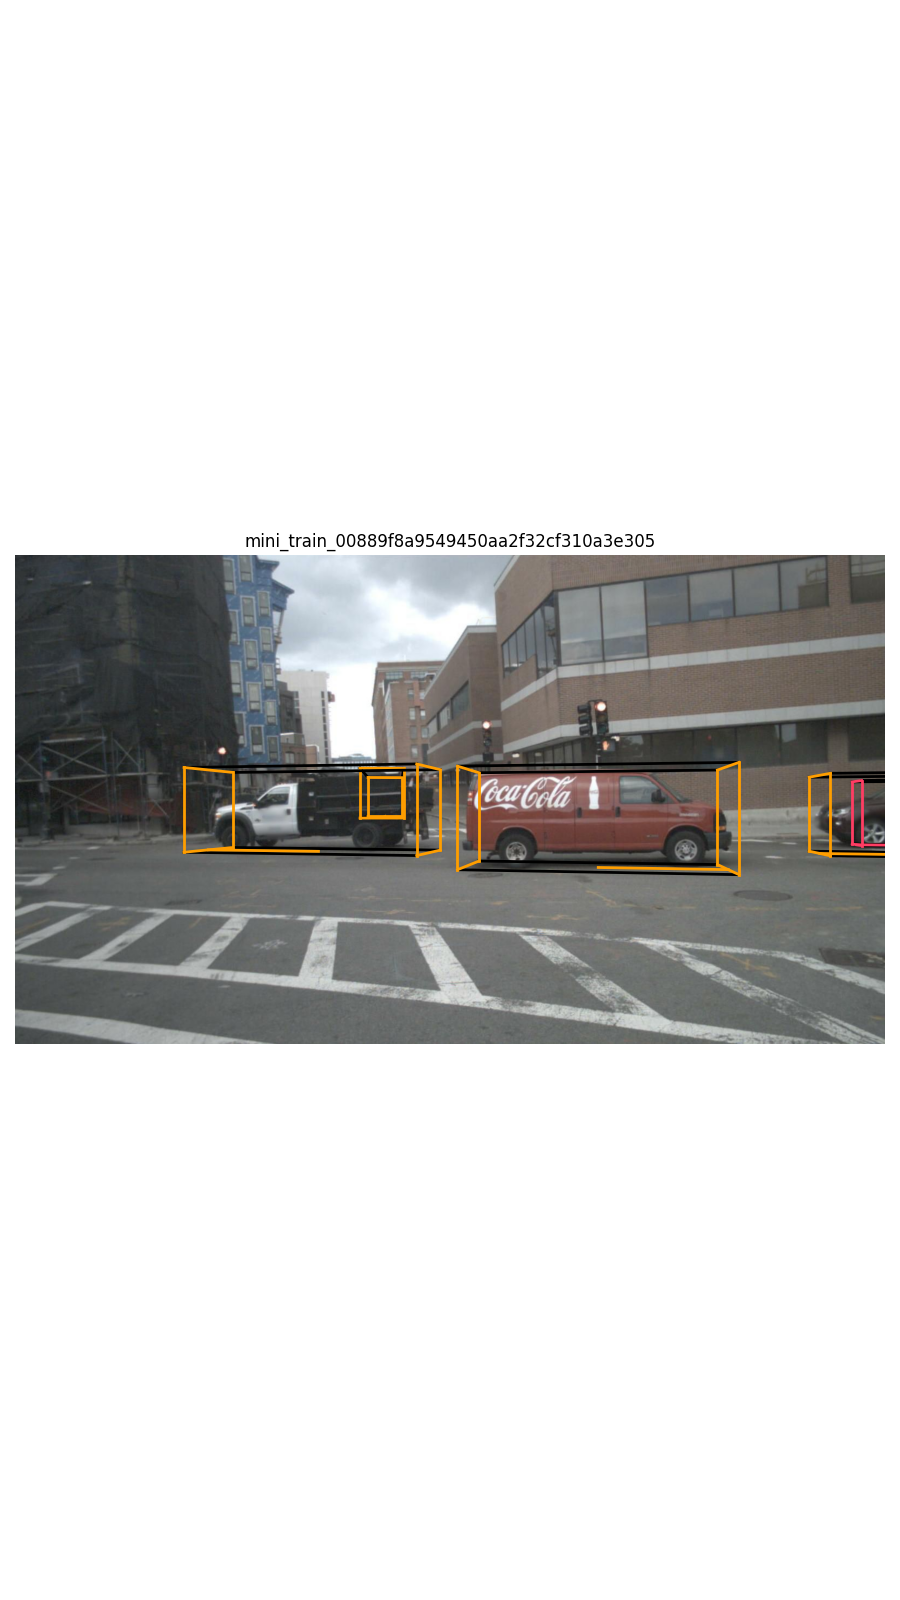

In [48]:
Image.open(all_renders[0]) if all_renders else None

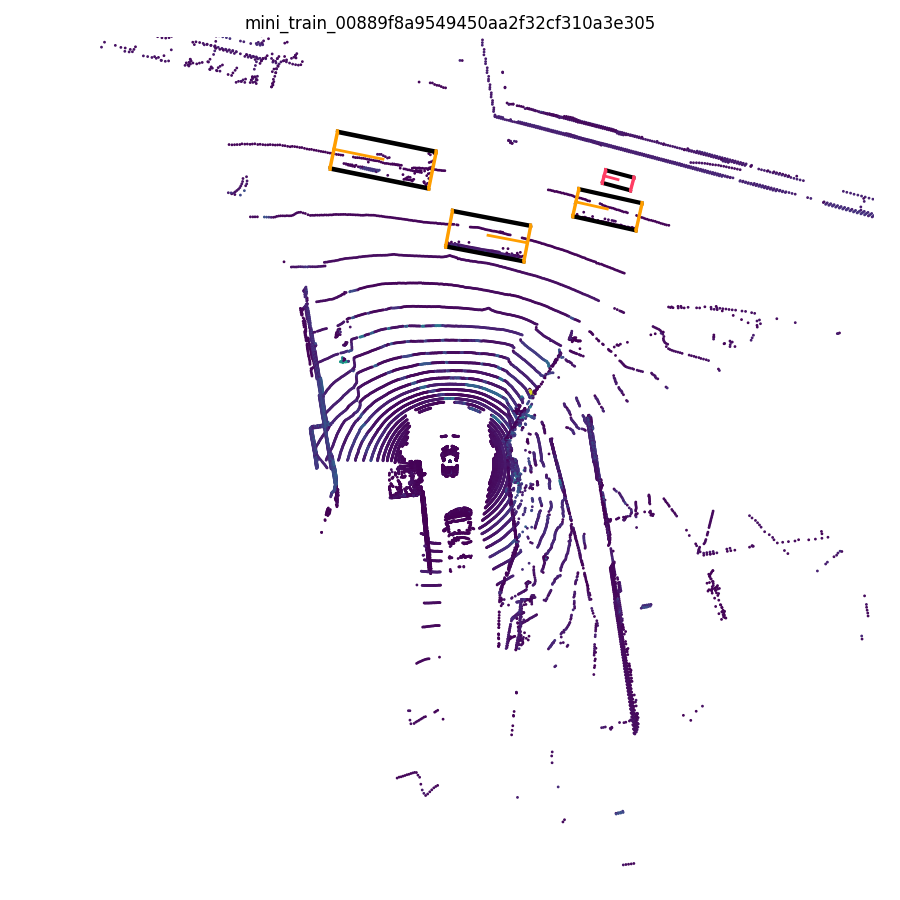

In [49]:
Image.open(all_renders[1]) if len(all_renders) > 1 else None

In [50]:
# If you want to export the full mini split, bump IMAGE_COUNT high enough.
# For example: IMAGE_COUNT = 10_000  (mini is much smaller than that).

In [51]:
# (Optional) cleanup converted output.
# !rm -rf {STORE_DIR}